In [159]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [160]:
# Data path
path_to_data = "Documents/data_analysis/data/GlobalLandTemperaturesByCountry.csv"

# Load Data
df = pd.read_csv(path_to_data)
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


In [161]:
# Data Cleaning, handling missing values

# Conver date column into date format
df['dt'] = pd.to_datetime(data['dt'])

#extract year to new column
df['year'] = df['dt'].dt.year

# Drop missing values
df = df.dropna(subset=['AverageTemperature'])

df.tail()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,year
577456,2013-04-01,21.142,0.495,Zimbabwe,2013.0
577457,2013-05-01,19.059,1.022,Zimbabwe,2013.0
577458,2013-06-01,17.613,0.473,Zimbabwe,2013.0
577459,2013-07-01,17.000,0.453,Zimbabwe,2013.0
577460,2013-08-01,19.759,0.717,Zimbabwe,2013.0


In [162]:
global_temp = df.groupby('year')['AverageTemperature'].mean().reset_index()


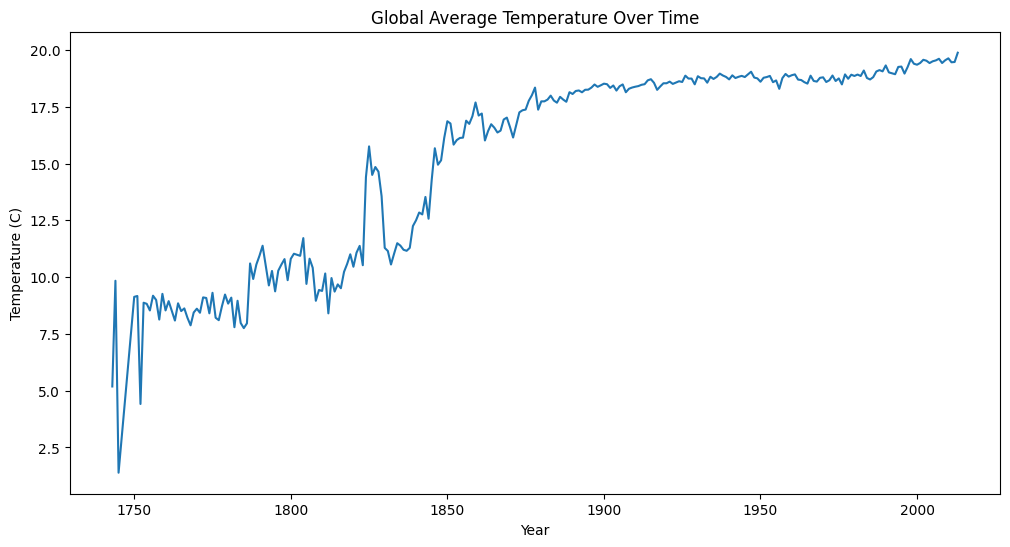

In [163]:
plt.figure(figsize=(12,6))
plt.plot(global_temp['year'], global_temp['AverageTemperature'])
plt.title("Global Average Temperature Over Time")
plt.xlabel("Year")
plt.ylabel("Temperature (C)")
plt.show()

In [55]:
# 10 highest temperature country
country_temp =df.groupby("Country")['AverageTemperature'].mean().sort_values(ascending=False).head(10)
country_temp


Country
Djibouti                28.816603
Mali                    28.441977
Burkina Faso            28.083507
Senegal                 27.967375
Aruba                   27.920390
United Arab Emirates    27.693995
Mauritania              27.620256
Gambia                  27.538552
Niger                   27.458973
Curaçao                 27.353415
Name: AverageTemperature, dtype: float64

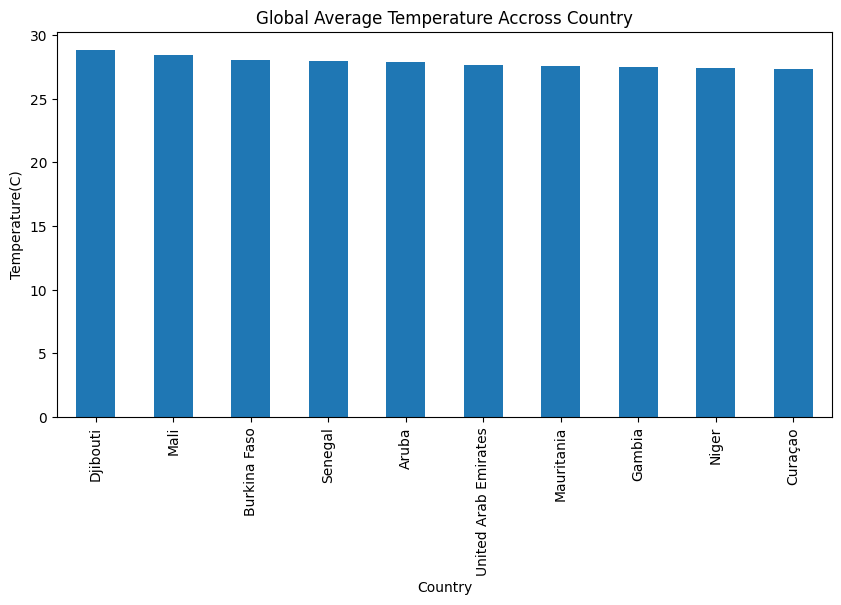

In [164]:
country_temp.plot(kind='bar', figsize=(10,5))
plt.title("Global Average Temperature Accross Country")
plt.xlabel("Country")
plt.ylabel("Temperature(C)")
plt.show()

In [165]:
#Predict Temperature
global_temp.head()




,year,AverageTemperature
0,1743.0,5.184140
1,1744.0,9.837898
2,1745.0,1.387125
3,1750.0,9.129353
4,1751.0,9.167388


In [301]:
# prepare ML libraries

import numpy as np

train = global_temp[
    (global_temp['year'] > 1970) & (global_temp['year'] <= 2000)
]
test = global_temp[global_temp['year'] > 2000]

train.columns

    

Index(['year', 'AverageTemperature', 'year_scaled'], dtype='str')

In [358]:
X_train = train[['year']]
X_test = test[['year']]
y_train = train['AverageTemperature']
y_test = test['AverageTemperature']


X_test

,year
254,2001.0
255,2002.0
256,2003.0
257,2004.0
258,2005.0
259,2006.0
260,2007.0
261,2008.0
262,2009.0
263,2010.0


In [303]:
# model selection : linear regression karena melihat trend extrapolation, bukan tren based on features
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# fit model
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [305]:
#make prediction
preds = model.predict(X_test)

In [306]:
# calculate mae

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, preds)
print("MAE: ", mae)

MAE:  0.10042485501110548


In [307]:
# MAE > 1 derajat Celcius, masih cukup besar.
# Gunakan alternatif model : Polynomial Regression
# Karena tren temperature bukan garis lurus

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

model_poly = make_pipeline(PolynomialFeatures(2), LinearRegression())





In [308]:
print(model_poly)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])


In [364]:
# fit
model.fit(X_train, y_train)
model_poly.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [365]:
pred_poly = model_poly.predict(X_test)
pred_linear = model.predict(X_test)

In [366]:
# calculate mae
mae_poly = mean_absolute_error(y_test, pred_poly)
mae_linear = mean_absolute_error(y_test, pred_linear)
print("MAE Polynomial: ", mae_poly)
print("MAE Linear : ", mae_linear)

MAE Polynomial:  0.1591560593798539
MAE Linear :  0.10042485501110548


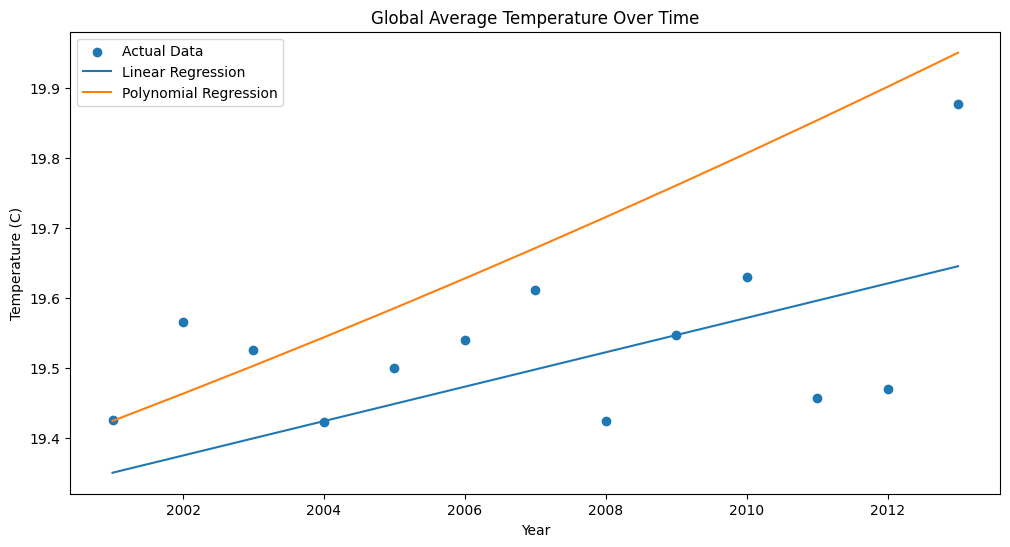

In [360]:
# Perbandingan before 2000 dan after 2000
global_temp

plt.figure(figsize=(12,6))

plt.title("Global Average Temperature Over Time")
plt.xlabel("Year")
plt.ylabel("Temperature (C)")

 #data asli
plt.scatter(X_test, y_test, label="Actual Data")

# data linear
plt.plot(X_test, pred_linear, label="Linear Regression")

# data polinomial
plt.plot(X_test, pred_poly, label="Polynomial Regression")

plt.legend()
plt.show()

In [368]:
## Predict data future

import numpy as np

until_present_year = pd.DataFrame({'year': [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]})
until_present_year

pred_future = model_poly.predict(until_present_year)
pred_future

array([19.95047859, 20.00019481, 20.05080762, 20.10231702, 20.15472301,
       20.20802559, 20.26222476, 20.31732052, 20.37331288, 20.43020183,
       20.48798737, 20.5466695 , 20.60624822, 20.66672353])

In [315]:
# Comparison model
# menggunakan seluruh all range tahun

X_all = global_temp[['year']] # double bracket karena dataframe
y_all = global_temp['AverageTemperature']

# fit
model.fit(X_all, y_all)
model_poly.fit(X_all, y_all)

# prediction
predict_linear = model.predict(X_all)
predict_poly = model_poly.predict(X_all)

In [314]:
# calculate mae
mae_poly_all = mean_absolute_error(y_all, predict_poly)
print("MAE Polynomial: ", mae_poly_all)

MAE Polynomial:  0.8977475089725022


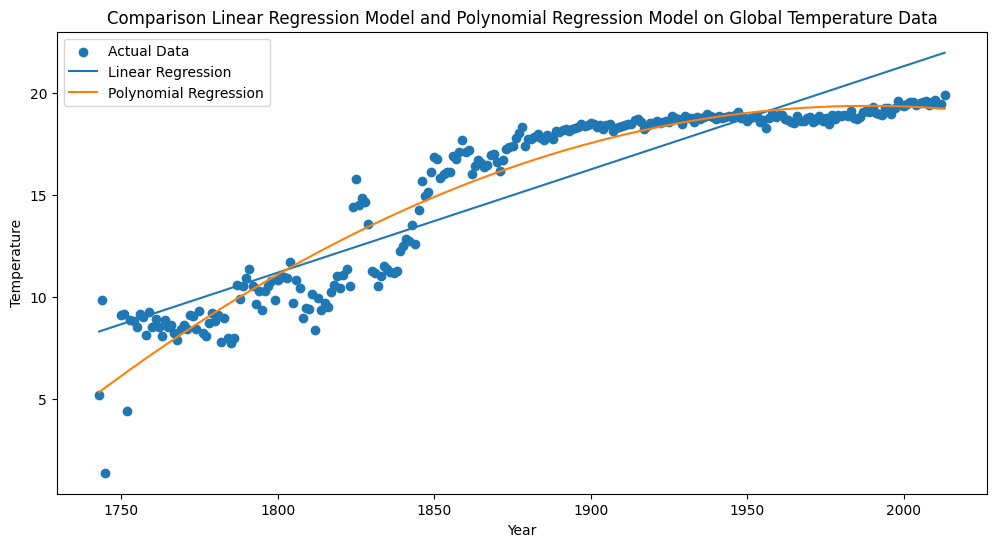

In [317]:
# compare actual data, linear regression prediction, polynomial prediction using all data

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.title("Comparison Linear Regression Model and Polynomial Regression Model on Global Temperature Data")
plt.xlabel("Year")
plt.ylabel("Temperature")

# data asli
plt.scatter(global_temp['year'], global_temp['AverageTemperature'], label="Actual Data")

# data linear
plt.plot(global_temp['year'], predict_linear, label="Linear Regression")

# data polinomial
plt.plot(global_temp['year'], predict_poly, label="Polynomial Regression")

plt.legend()

In [318]:
# Predict data future

import numpy as np

until_present_year = pd.DataFrame({'year': [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]})
until_present_year


,year
0,2013
1,2014
2,2015
3,2016
4,2017
5,2018
6,2019
7,2020
8,2021
9,2022


In [319]:
until_present_year_prediction = model_poly.predict(until_present_year)

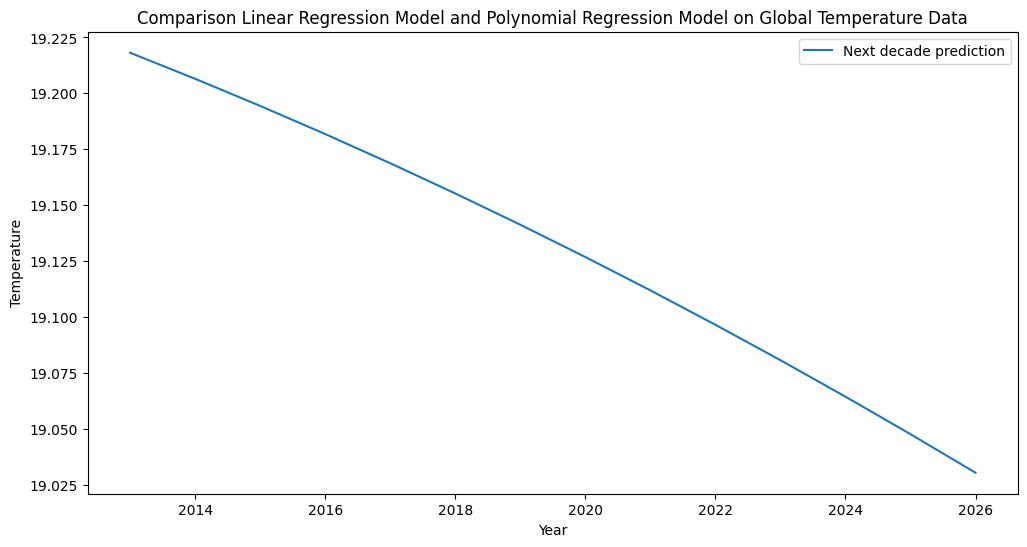

In [361]:
filtered = global_temp[global_temp['year'] >= 2000]


import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.title("Comparison Linear Regression Model and Polynomial Regression Model on Global Temperature Data")
plt.xlabel("Year")
plt.ylabel("Temperature")

# data asli
#plt.scatter(filtered['year'], filtered['AverageTemperature'], label="Actual Data")

# data linear
#plt.plot(filtered['year'], predict_linear[filtered.index], label="Linear Regression")

# data polinomial
#plt.plot(filtered['year'], predict_poly[filtered.index], label="Polynomial Regression")

# until present
plt.plot(until_present_year, until_present_year_prediction, label="Next decade prediction" )

plt.legend()
plt.show()

In [ ]:
# hasil plot tidak masuk akal karena ada penurunan di polynomial regression dan kenaikan yang terlalu besar pada linear regression. 
# oleh karena itu kita perlu mengubah appoach year menggunakan year_scale

In [321]:
# year_scaled ---> year 0, year 1, year 2,....
global_temp['year_scaled'] = global_temp['year'] - global_temp['year'].min()

In [322]:
X_all = global_temp[['year_scaled']]
y_all = global_temp[['AverageTemperature']]

model.fit(X_all, y_all)
model_poly.fit(X_all, y_all)





,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [323]:
preds_linear = model.predict(X_all)
preds_poly = model_poly.predict(X_all)



In [324]:
# calculate mae
mae_polys = mean_absolute_error(y_all, preds_poly)
print("MAE Polynomial: ", mae_polys)

MAE Polynomial:  0.8977475089764604


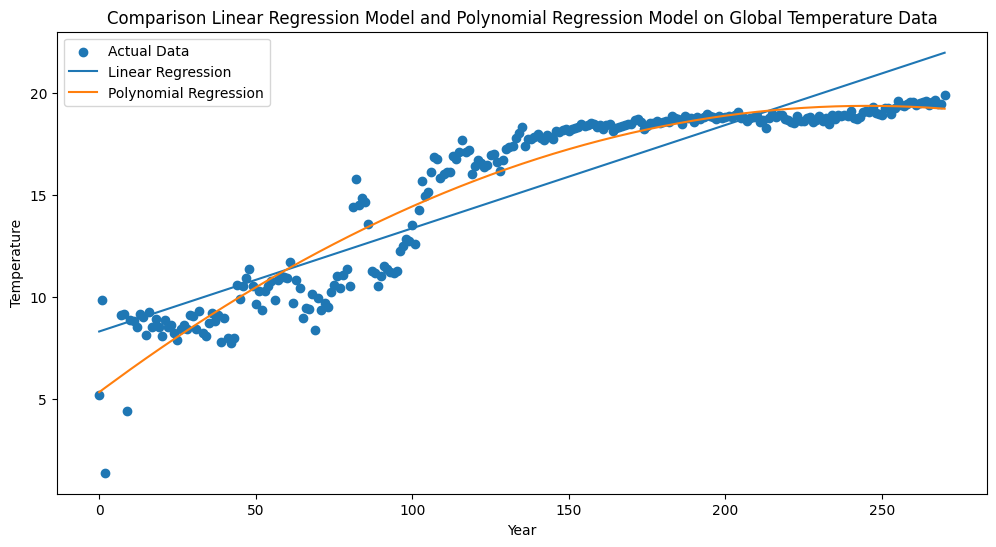

In [325]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.title("Comparison Linear Regression Model and Polynomial Regression Model on Global Temperature Data")
plt.xlabel("Year")
plt.ylabel("Temperature")

# data asli
plt.scatter(global_temp['year_scaled'], global_temp['AverageTemperature'], label="Actual Data")

# data linear
plt.plot(global_temp['year_scaled'], preds_linear, label="Linear Regression")

# data polinomial
plt.plot(global_temp['year_scaled'], preds_poly, label="Polynomial Regression")

plt.legend()
plt.show()

In [327]:
#Train test split lebih efektif daripada x_all y_all


In [244]:
'''Models trained on pre-2000 data failed to capture recent accelerated warming trends, leading to unrealistic downward predictions. 
    Using more recent data improved forecasting accuracy.'''

In [336]:
# year_scaled ---> year 0, year 1, year 2,....
global_temp['year_scaled'] = global_temp['year'] - global_temp['year'].min()

train = global_temp[
    (global_temp['year'] > 1970) & (global_temp['year'] <= 2000)
]
test = global_temp[global_temp['year'] > 2000]

X_train = train[['year_scaled']]
X_test = test[['year_scaled']]
y_train = train[['AverageTemperature']]
y_test = test[['AverageTemperature']]

In [337]:
model.fit(X_train, y_train)
model_poly.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [339]:
predict_linear_data = model.predict(X_test)
predict_poly_data = model_poly.predict(X_test)



In [340]:
# calculate MAE
mae_linear_data = mean_absolute_error(y_test, predict_linear_data)
mae_polys_data = mean_absolute_error(y_test, predict_poly_data)
print("MAE Linear: ", mae_linear_data)
print("MAE Polynomial: ", mae_polys_data)


MAE Linear:  0.10042485501110522
MAE Polynomial:  0.15915605934338992


In [341]:
import numpy as np

next_year = pd.DataFrame({'year': [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]})
next_year['year_scaled'] = next_year['year'] - global_temp['year'].min()


In [342]:
pred_next_year = model_poly.predict(next_year[['year_scaled']])
pred_next_year

array([[19.95047859],
       [20.00019481],
       [20.05080762],
       [20.10231702],
       [20.15472301],
       [20.20802559],
       [20.26222476],
       [20.31732052],
       [20.37331288],
       [20.43020183],
       [20.48798737],
       [20.5466695 ],
       [20.60624822],
       [20.66672353]])